## Dataset and Data Gathering
- Dataset file: `hourly_data.csv`
- Topic: Hourly weather observations across multiple cities
- Source method: Weather API / scraped weather observations consolidated into CSV for Spark processing

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.functions import col, when, avg, to_timestamp, hour, month, to_date, round as spark_round, max as spark_max, min as spark_min, sum as spark_sum, isnan
import matplotlib.pyplot as plt
from functools import reduce
import os
import re

spark = SparkSession.builder.appName("WeatherFullDatasetPreprocessing").getOrCreate()
os.makedirs("analysis_assets", exist_ok=True)

In [14]:
# StructType schema
schema = StructType([
    StructField("city_name", StringType(), True),
    StructField("datetime", StringType(), True),
    StructField("temperature_2m", DoubleType(), True),
    StructField("relative_humidity_2m", DoubleType(), True),
    StructField("dew_point_2m", DoubleType(), True),
    StructField("apparent_temperature", DoubleType(), True),
    StructField("precipitation", DoubleType(), True),
    StructField("rain", DoubleType(), True),
    StructField("snowfall", DoubleType(), True),
    StructField("snow_depth", DoubleType(), True),
    StructField("weather_code", DoubleType(), True),
    StructField("pressure_msl", DoubleType(), True),
    StructField("surface_pressure", DoubleType(), True),
    StructField("cloud_cover", DoubleType(), True),
    StructField("cloud_cover_low", DoubleType(), True),
    StructField("cloud_cover_mid", DoubleType(), True),
    StructField("cloud_cover_high", DoubleType(), True),
    StructField("et0_fao_evapotranspiration", DoubleType(), True),
    StructField("vapour_pressure_deficit", DoubleType(), True),
    StructField("wind_speed_10m", DoubleType(), True),
    StructField("wind_speed_100m", DoubleType(), True),
    StructField("wind_direction_10m", DoubleType(), True),
    StructField("wind_direction_100m", DoubleType(), True),
    StructField("wind_gusts_10m", DoubleType(), True),
    StructField("soil_temperature_0_to_7cm", DoubleType(), True),
    StructField("soil_temperature_7_to_28cm", DoubleType(), True),
    StructField("soil_temperature_28_to_100cm", DoubleType(), True),
    StructField("soil_temperature_100_to_255cm", DoubleType(), True),
    StructField("soil_moisture_0_to_7cm", DoubleType(), True),
    StructField("soil_moisture_7_to_28cm", DoubleType(), True),
    StructField("soil_moisture_28_to_100cm", DoubleType(), True),
    StructField("soil_moisture_100_to_255cm", DoubleType(), True),
    StructField("shortwave_radiation", DoubleType(), True),
    StructField("direct_radiation", DoubleType(), True),
    StructField("diffuse_radiation", DoubleType(), True),
    StructField("direct_normal_irradiance", DoubleType(), True),
    StructField("global_tilted_irradiance", DoubleType(), True),
    StructField("terrestrial_radiation", DoubleType(), True),
    StructField("shortwave_radiation_instant", DoubleType(), True),
    StructField("direct_radiation_instant", DoubleType(), True),
    StructField("diffuse_radiation_instant", DoubleType(), True),
    StructField("direct_normal_irradiance_instant", DoubleType(), True),
    StructField("global_tilted_irradiance_instant", DoubleType(), True),
    StructField("terrestrial_radiation_instant", DoubleType(), True)
])

raw_df = spark.read.csv("hourly_data.csv", header=True, schema=schema)
df_full = raw_df.cache()

print("Raw rows:", raw_df.count())
print("Rows used:", df_full.count())
print("Columns:", len(df_full.columns))

Raw rows: 1499328
Rows used: 1499328
Columns: 44


In [15]:
def eda_matplotlib(df, title, sample_n=50000):
    print(f"\n===== EDA CHECKPOINT: {title} =====")
    total_rows = df.count()
    print("Rows:", total_rows, "Columns:", len(df.columns))

    missing_conditions = []
    for c, t in df.dtypes:
        cond = col(c).isNull()
        if t in ("double", "float"):
            cond = cond | isnan(col(c))
        missing_conditions.append(cond)

    rows_with_missing = 0
    if missing_conditions:
        rows_with_missing = df.filter(reduce(lambda a, b: a | b, missing_conditions)).count()
    print("Rows with at least one missing value:", rows_with_missing)

    metrics = [c for c in ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m", "apparent_temperature"] if c in df.columns]
    if metrics:
        df.select(*metrics).describe().show()

    plot_cols = [c for c in ["temperature_2m", "relative_humidity_2m", "precipitation"] if c in df.columns]
    if len(plot_cols) < 2:
        return

    fraction = min(1.0, sample_n / max(1, total_rows))
    pdf = df.sample(False, fraction, 42).select(*plot_cols).dropna().toPandas()
    if pdf.empty:
        return

    fig, ax = plt.subplots(1, 3, figsize=(19, 5))
    ax[0].hist(pdf["temperature_2m"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
    ax[0].set_title(f"{title}: Temperature Distribution")
    ax[1].scatter(pdf["temperature_2m"], pdf["relative_humidity_2m"], s=8, alpha=0.3, color="darkorange")
    ax[1].set_title(f"{title}: Temp vs Humidity")
    ax[2].boxplot(pdf["precipitation"], vert=True)
    ax[2].set_title(f"{title}: Precipitation Boxplot")
    plt.tight_layout()

    safe = re.sub(r"[^a-zA-Z0-9]+", "_", title.strip().lower()).strip("_")
    path = os.path.join("analysis_assets", f"{safe}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved plot:", path)
    plt.show()


===== EDA CHECKPOINT: Step 1 - Raw Full Dataset =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 269000
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|  count|           1491930|             1491930|            1491930|          1491930|             1491930|
|   mean|26.996553524629128|   80.23429249361565|0.27922308687398834|9.304811217684621|  31.411685534844093|
| stddev|2.9356353591760356|  13.629631833769947| 1.0461154279108915|6.291523351602621|  3.6222541033782734|
|    min|               8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|              40.5|               100.0|               77.6|             72.3|                45.6|
+-

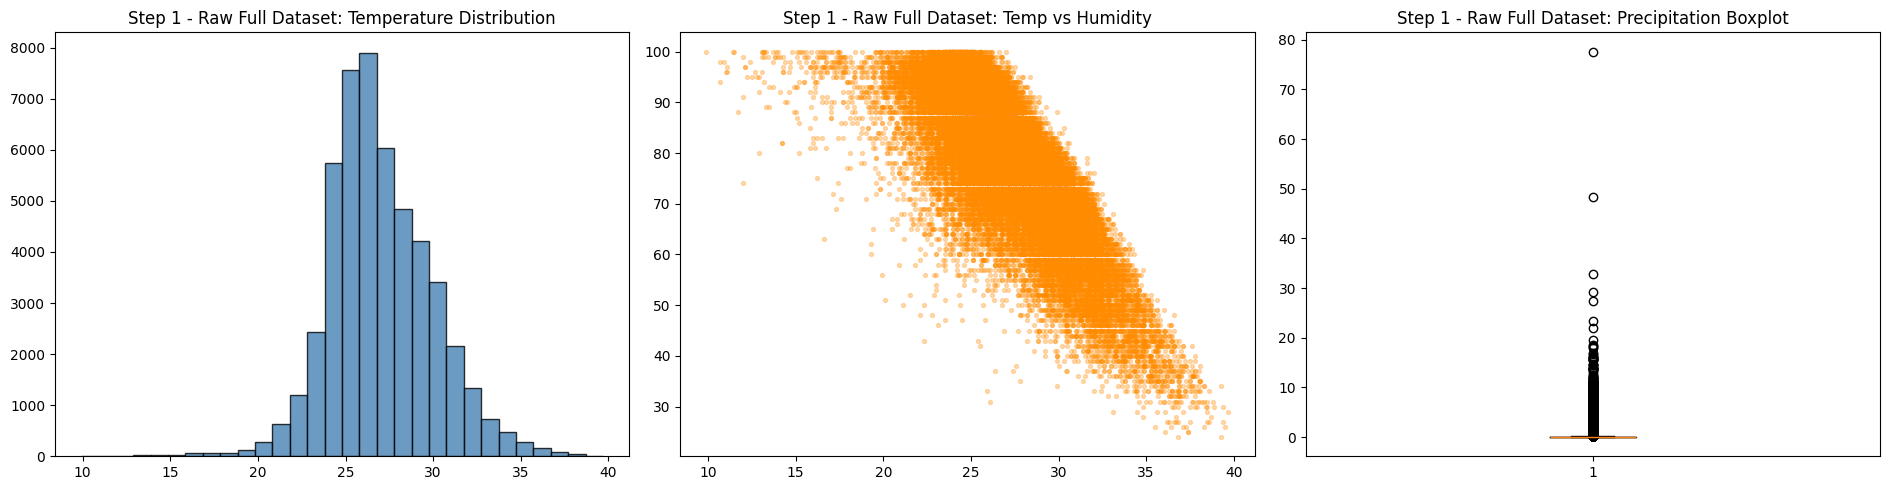

In [16]:
# Step 1: Raw full dataset
eda_matplotlib(df_full, "Step 1 - Raw Full Dataset")


===== EDA CHECKPOINT: Step 2 - After Fill Missing Values =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 0
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|  count|           1499328|             1499328|            1499328|          1499328|             1499328|
|   mean|26.996553524628702|   80.23429249361527|0.27922308687398434| 9.30481121768465|  31.411685534843787|
| stddev|2.9283838767474455|   13.59596449308952| 1.0435313577810397|6.275982296447151|  3.6133065643385573|
|    min|               8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|              40.5|               100.0|               77.6|             72.3|                45.6

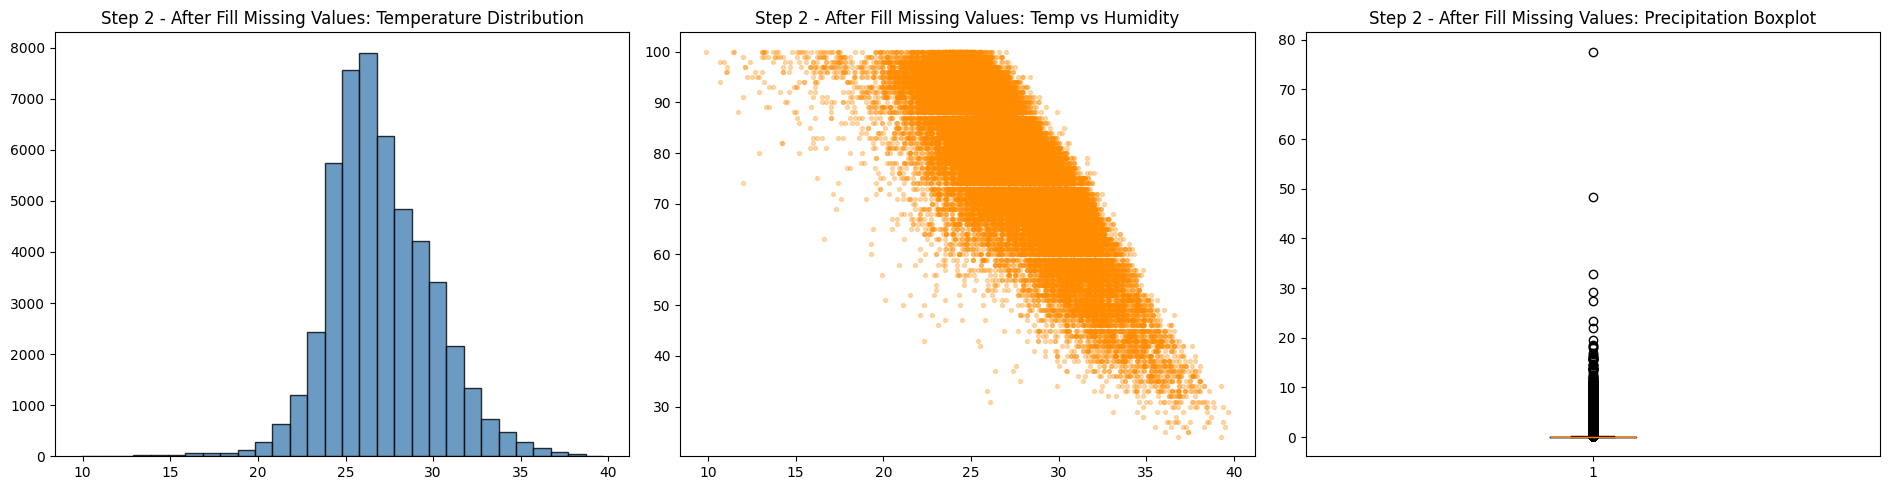

In [17]:
# Step 2: Fill missing values
numeric_cols = [c for c, t in df_full.dtypes if t in ("double", "int", "bigint", "float")]
means_row = df_full.select([avg(col(c)).alias(c) for c in numeric_cols]).collect()[0].asDict()
fill_map = {k: float(v) for k, v in means_row.items() if v is not None}
df_filled = df_full.fillna(fill_map).fillna({"city_name": "Unknown"})
eda_matplotlib(df_filled, "Step 2 - After Fill Missing Values")

Rows before deduplication: 1499328
Rows after deduplication: 1499328

===== EDA CHECKPOINT: Step 3 - After Deduplication =====
Rows: 1499328 Columns: 44
Rows with at least one missing value: 0
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|      precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+-------------------+-----------------+--------------------+
|  count|           1499328|             1499328|            1499328|          1499328|             1499328|
|   mean|26.996553524629107|   80.23429249361584|0.27922308687404906|9.304811217684472|   31.41168553484412|
| stddev| 2.928383876747431|  13.595964493089522|   1.04353135778104|6.275982296447143|  3.6133065643385636|
|    min|               8.7|                20.0|                0.0|              0.0|                 7.5|
|    max|              40.5|               1

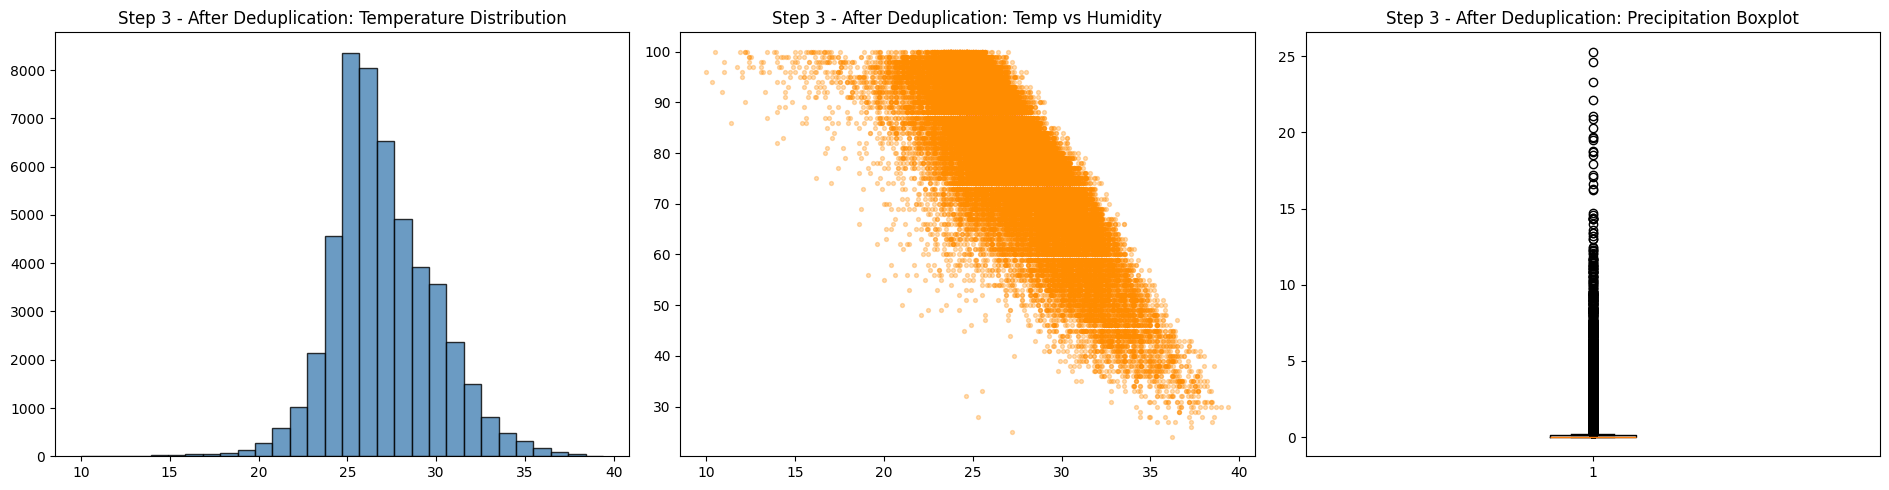

In [18]:
# Step 3: Deduplicate
# Use conservative shuffle settings for low-memory local execution
spark.conf.set("spark.sql.adaptive.enabled", "false")
spark.conf.set("spark.sql.shuffle.partitions", "1200")

rows_before = df_filled.count()

# Deduplicate by natural hourly key instead of whole-row distinct
# (whole-row dedup is much heavier for wide datasets)
df_clean = (
    df_filled
    .dropna(subset=["city_name", "datetime"])
    .repartition(1200, "city_name", "datetime")
    .dropDuplicates(["city_name", "datetime"])
)

rows_after = df_clean.count()
print("Rows before deduplication:", rows_before)
print("Rows after deduplication:", rows_after)
eda_matplotlib(df_clean, "Step 3 - After Deduplication")

Rows after filtering: 1499309

===== EDA CHECKPOINT: Step 4 - After Filtering Invalid Records =====
Rows: 1499309 Columns: 44
Rows with at least one missing value: 0
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|     precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|  count|           1499309|             1499309|           1499309|          1499309|             1499309|
|   mean|26.996775583268775|   80.23409670446055|0.2792266253298648|9.304850496721107|  31.411978617874485|
| stddev|2.9277377102750055|  13.595936106168413|1.0435374964375064|6.276010739719112|   3.612390870411463|
|    min|              10.0|                20.0|               0.0|              0.0|                 8.9|
|    max|              40.5|               100.0|              77.6|          

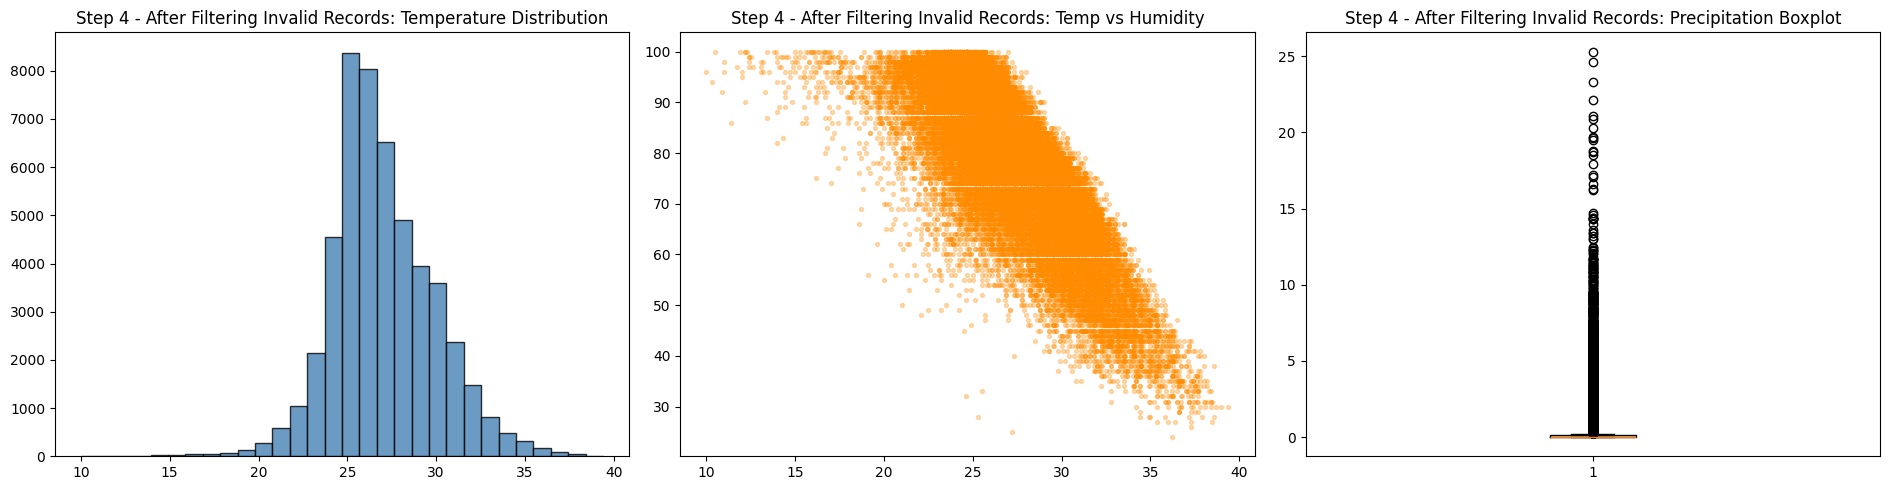

In [19]:
# Step 4: Filter invalid records
filtered_df = df_clean.filter(
    (col("temperature_2m") >= 10) & (col("temperature_2m") <= 50) &
    (col("relative_humidity_2m") >= 0) & (col("relative_humidity_2m") <= 100) &
    (col("precipitation") >= 0) &
    (col("wind_speed_10m") >= 0) &
    (col("city_name") != "")
).cache()
print("Rows after filtering:", filtered_df.count())
eda_matplotlib(filtered_df, "Step 4 - After Filtering Invalid Records")

root
 |-- datetime: timestamp (nullable = true)
 |-- weather_code: integer (nullable = true)
 |-- snow_depth: double (nullable = false)


===== EDA CHECKPOINT: Step 5 - After Type Conversion =====
Rows: 1499309 Columns: 44
Rows with at least one missing value: 0
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|     precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|  count|           1499309|             1499309|           1499309|          1499309|             1499309|
|   mean|26.996775583268775|   80.23409670446055|0.2792266253298648|9.304850496721107|  31.411978617874485|
| stddev|2.9277377102750055|  13.595936106168413|1.0435374964375064|6.276010739719112|   3.612390870411463|
|    min|              10.0|                20.0|               0.0|              0.0|   

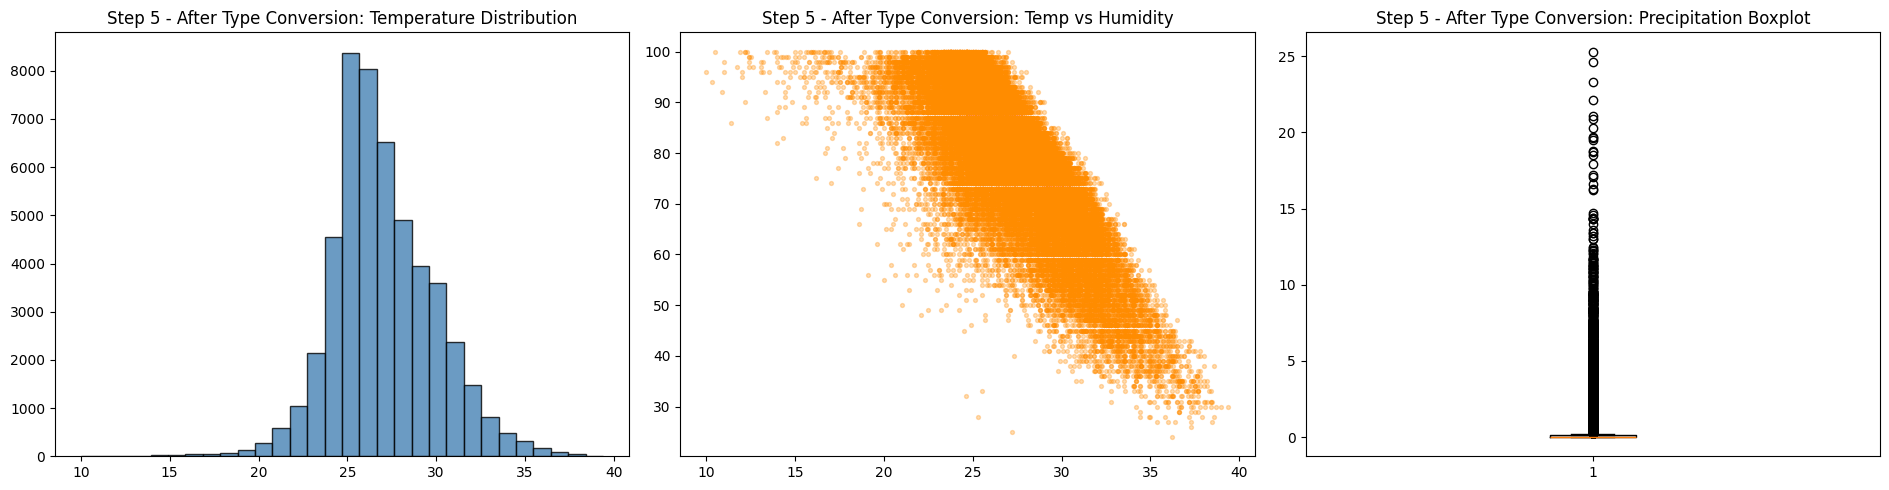

In [20]:
# Step 5: Type conversion
typed_df = (
    filtered_df
    .withColumn("datetime", to_timestamp(col("datetime"), "yyyy-MM-dd HH:mm:ss"))
    .withColumn("weather_code", col("weather_code").cast(IntegerType()))
    .withColumn("snow_depth", col("snow_depth").cast(DoubleType()))
)
typed_df.select("datetime", "weather_code", "snow_depth").printSchema()
eda_matplotlib(typed_df, "Step 5 - After Type Conversion")


===== EDA CHECKPOINT: Step 6 - After Feature Engineering =====
Rows: 1499309 Columns: 49
Rows with at least one missing value: 0
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|summary|    temperature_2m|relative_humidity_2m|     precipitation|   wind_speed_10m|apparent_temperature|
+-------+------------------+--------------------+------------------+-----------------+--------------------+
|  count|           1499309|             1499309|           1499309|          1499309|             1499309|
|   mean|26.996775583268775|   80.23409670446055|0.2792266253298648|9.304850496721107|  31.411978617874485|
| stddev|2.9277377102750055|  13.595936106168413|1.0435374964375064|6.276010739719112|   3.612390870411463|
|    min|              10.0|                20.0|               0.0|              0.0|                 8.9|
|    max|              40.5|               100.0|              77.6|             72.3|                45.6|
+-----

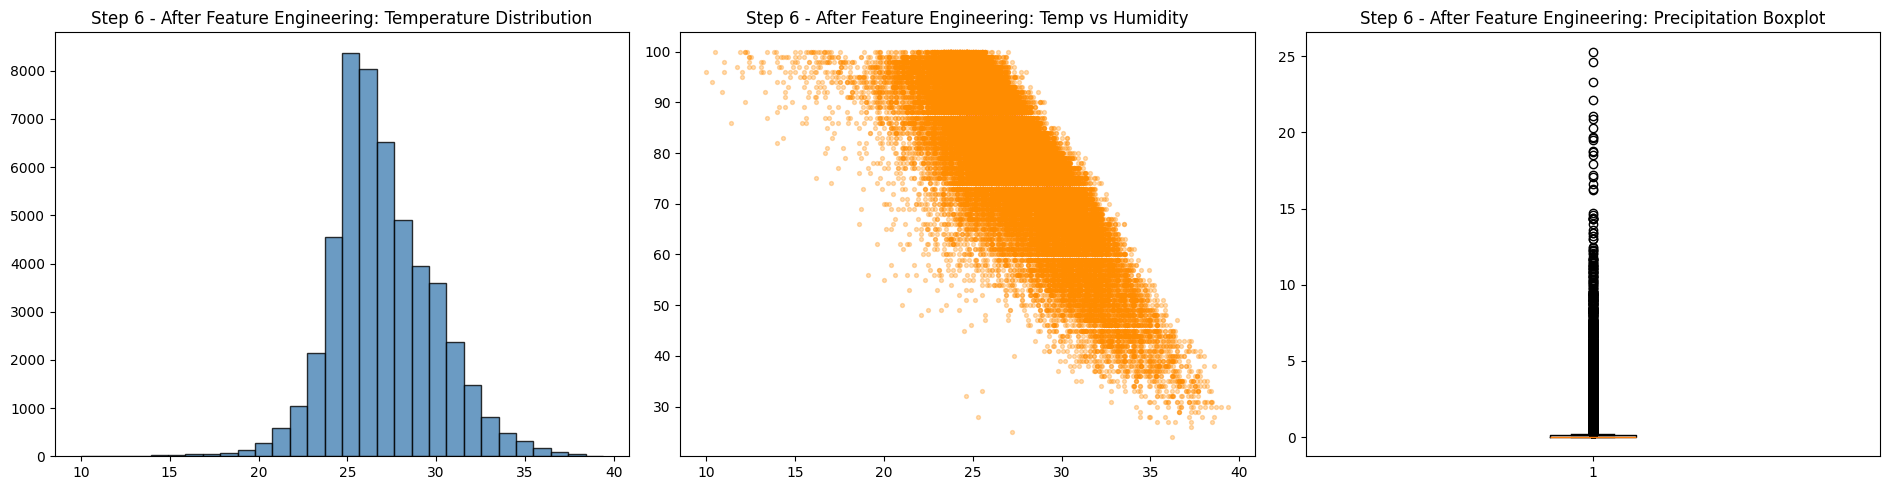

In [21]:
# Step 6: Feature engineering
enriched_df = (
    typed_df
    .withColumn("temperature_f", (col("temperature_2m") * 9 / 5) + 32)
    .withColumn("is_raining", col("rain") > 0)
    .withColumn(
        "heat_category",
        when(col("apparent_temperature") < 26, "Cool")
        .when((col("apparent_temperature") >= 26) & (col("apparent_temperature") < 32), "Comfortable")
        .when((col("apparent_temperature") >= 32) & (col("apparent_temperature") < 38), "Hot")
        .otherwise("Very Hot")
    )
    .withColumn("hour", hour(col("datetime")))
    .withColumn("month", month(col("datetime")))
)
eda_matplotlib(enriched_df, "Step 6 - After Feature Engineering")

Daily summary rows: 62472
Daily rows with missing values: 0
Saved plot: analysis_assets\step7_daily_summary_eda.png


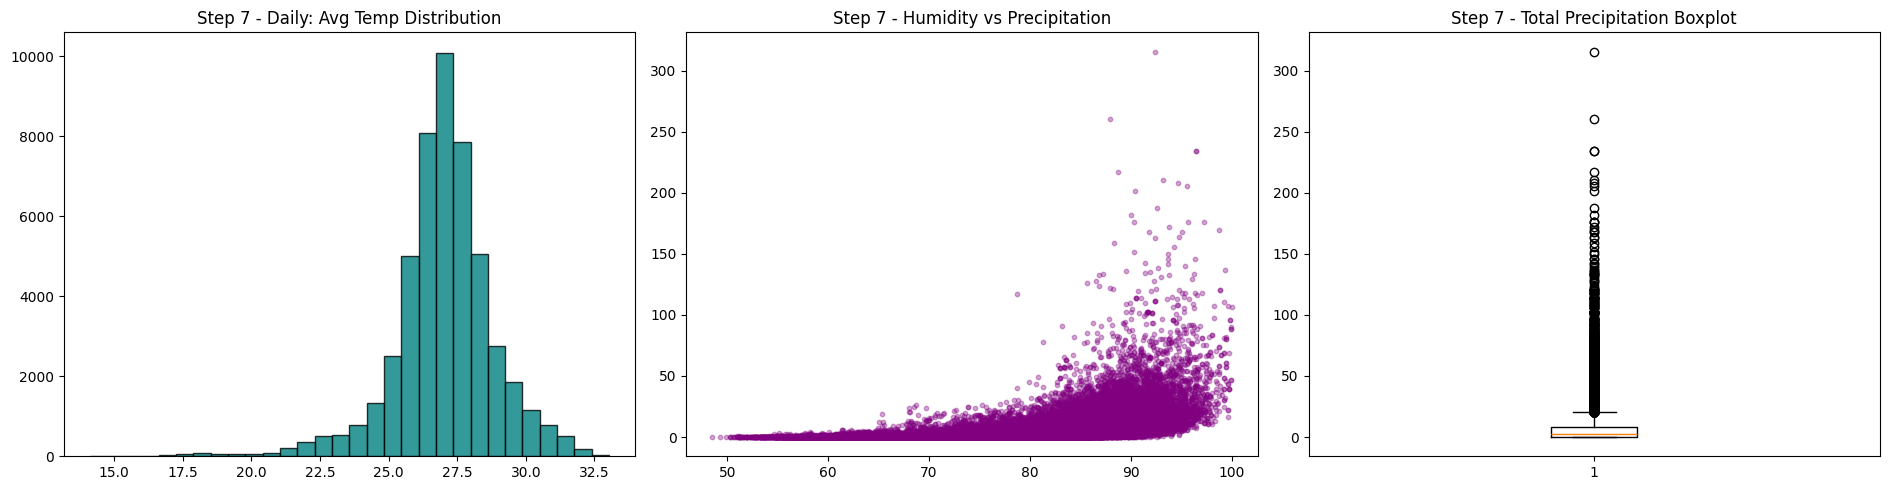

In [22]:
# Step 7: Daily aggregate + EDA
daily_summary = (
    enriched_df.withColumn("date", to_date(col("datetime")))
    .groupBy("city_name", "date")
    .agg(
        spark_round(avg("temperature_2m"), 2).alias("avg_temp_c"),
        spark_round(spark_max("temperature_2m"), 2).alias("max_temp_c"),
        spark_round(spark_min("temperature_2m"), 2).alias("min_temp_c"),
        spark_round(spark_sum("precipitation"), 2).alias("total_precipitation_mm"),
        spark_round(avg("relative_humidity_2m"), 2).alias("avg_humidity_pct"),
        spark_round(spark_max("wind_speed_10m"), 2).alias("max_wind_speed_kmh"),
        spark_sum(col("is_raining").cast("int")).alias("rainy_hours")
    )
)

print("Daily summary rows:", daily_summary.count())
daily_missing_cond = (
    col("city_name").isNull() | col("date").isNull() | col("avg_temp_c").isNull() |
    col("max_temp_c").isNull() | col("min_temp_c").isNull() | col("total_precipitation_mm").isNull() |
    col("avg_humidity_pct").isNull() | col("max_wind_speed_kmh").isNull() | col("rainy_hours").isNull()
)
print("Daily rows with missing values:", daily_summary.filter(daily_missing_cond).count())

daily_pdf = daily_summary.select("avg_temp_c", "total_precipitation_mm", "avg_humidity_pct").dropna().limit(50000).toPandas()
if not daily_pdf.empty:
    fig, ax = plt.subplots(1, 3, figsize=(19, 5))
    ax[0].hist(daily_pdf["avg_temp_c"], bins=30, color="teal", edgecolor="black", alpha=0.8)
    ax[0].set_title("Step 7 - Daily: Avg Temp Distribution")
    ax[1].scatter(daily_pdf["avg_humidity_pct"], daily_pdf["total_precipitation_mm"], s=10, alpha=0.35, color="purple")
    ax[1].set_title("Step 7 - Humidity vs Precipitation")
    ax[2].boxplot(daily_pdf["total_precipitation_mm"], vert=True)
    ax[2].set_title("Step 7 - Total Precipitation Boxplot")
    plt.tight_layout()
    step7_path = os.path.join("analysis_assets", "step7_daily_summary_eda.png")
    fig.savefig(step7_path, dpi=150, bbox_inches="tight")
    print("Saved plot:", step7_path)
    plt.show()

In [23]:
# Step 8: Save cleaned datasets (Windows-safe)
output_clean_parquet = "cleaned_weather_full.parquet"
output_daily_parquet = "daily_summary_full.parquet"
output_clean_csv_dir = "cleaned_weather_full_csv"
output_daily_csv_dir = "daily_summary_full_csv"
output_clean_csv_file = "cleaned_weather_full.csv"
output_daily_csv_file = "daily_summary_full.csv"

cleaned_project_df = enriched_df.select(
    "city_name", "datetime", "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "wind_speed_10m", "pressure_msl", "cloud_cover",
    "temperature_f", "is_raining", "heat_category", "hour", "month"
)

try:
    cleaned_project_df.write.mode("overwrite").option("header", True).csv(output_clean_csv_dir)
    daily_summary.write.mode("overwrite").option("header", True).csv(output_daily_csv_dir)
    print("Spark CSV export: SUCCESS")
except Exception as e:
    print("Spark CSV export failed. Using pandas fallback.")
    print("Reason:", str(e)[:250], "...")
    cleaned_project_df.toPandas().to_csv(output_clean_csv_file, index=False)
    daily_summary.toPandas().to_csv(output_daily_csv_file, index=False)
    print("Pandas CSV export: SUCCESS")

try:
    cleaned_project_df.write.mode("overwrite").parquet(output_clean_parquet)
    daily_summary.write.mode("overwrite").parquet(output_daily_parquet)
    print("Spark Parquet export: SUCCESS")
except Exception as e:
    print("Spark Parquet export skipped (likely winutils/HADOOP_HOME issue).")
    print("Reason:", str(e)[:250], "...")

Spark CSV export failed. Using pandas fallback.
Reason: An error occurred while calling o6060.csv.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems ...
Pandas CSV export: SUCCESS
Spark Parquet export skipped (likely winutils/HADOOP_HOME issue).
Reason: An error occurred while calling o6076.parquet.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProb ...


Before rows: 1499328
After rows: 1499309
Before rows with missing: 269000
After rows with missing: 0
Saved plot: analysis_assets\step9_before_vs_after_comparison.png


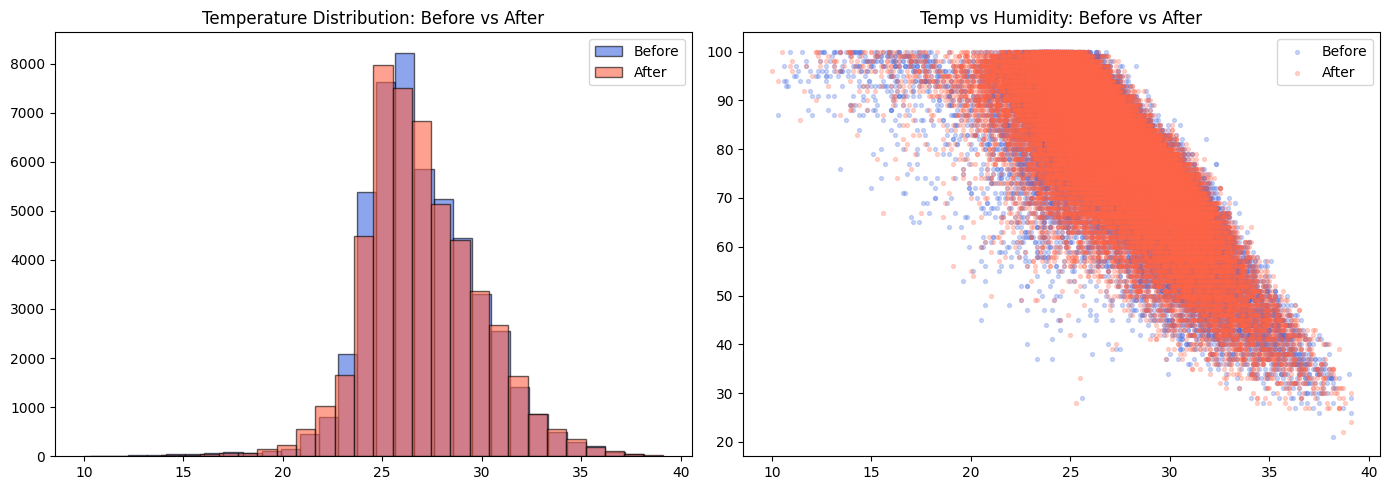

In [24]:
# Step 9: Before vs After EDA comparison
print("Before rows:", df_full.count())
print("After rows:", cleaned_project_df.count())
print("Before rows with missing:", df_full.filter(reduce(lambda a,b: a|b, [col(c).isNull() | (isnan(col(c)) if t in ('double','float') else col(c).isNull()) for c,t in df_full.dtypes])).count())
print("After rows with missing:", cleaned_project_df.filter(reduce(lambda a,b: a|b, [col(c).isNull() | (isnan(col(c)) if t in ('double','float') else col(c).isNull()) for c,t in cleaned_project_df.dtypes])).count())

before_pdf = df_full.select("temperature_2m", "relative_humidity_2m").dropna().sample(False, 0.06, 42).limit(50000).toPandas()
after_pdf = cleaned_project_df.select("temperature_2m", "relative_humidity_2m").dropna().sample(False, 0.06, 42).limit(50000).toPandas()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(before_pdf["temperature_2m"], bins=30, alpha=0.6, label="Before", color="royalblue", edgecolor="black")
ax[0].hist(after_pdf["temperature_2m"], bins=30, alpha=0.6, label="After", color="tomato", edgecolor="black")
ax[0].set_title("Temperature Distribution: Before vs After")
ax[0].legend()

ax[1].scatter(before_pdf["temperature_2m"], before_pdf["relative_humidity_2m"], s=8, alpha=0.25, label="Before", color="royalblue")
ax[1].scatter(after_pdf["temperature_2m"], after_pdf["relative_humidity_2m"], s=8, alpha=0.25, label="After", color="tomato")
ax[1].set_title("Temp vs Humidity: Before vs After")
ax[1].legend()
plt.tight_layout()
step9_path = os.path.join("analysis_assets", "step9_before_vs_after_comparison.png")
fig.savefig(step9_path, dpi=150, bbox_inches="tight")
print("Saved plot:", step9_path)
plt.show()

## Step 10: Model Algorithm Selection and Baseline Modeling (K-Means)

### Chosen Problem Setup
- **Primary task:** Unsupervised clustering of weather conditions (pattern discovery).
- **Goal:** Group similar hourly weather records into interpretable weather clusters.
- **Input features:** `temperature_2m`, `relative_humidity_2m`, `apparent_temperature`, `precipitation`, `wind_speed_10m`, `pressure_msl`, `cloud_cover`, `hour`, `month`

### Why K-Means
1. **Simple and strong baseline** for unlabeled tabular data.
2. **Fast to train** on large datasets and easy to reproduce.
3. Produces **interpretable centroids** that can represent typical weather patterns.

### External Model Basis / References
- Scikit-learn KMeans documentation: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- Scikit-learn silhouette_score documentation: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

In [25]:
# Step 10.1: Prepare Spark dataset for K-Means clustering
import random
import numpy as np
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

cluster_cols = [
    "temperature_2m", "relative_humidity_2m", "apparent_temperature", "precipitation",
    "wind_speed_10m", "pressure_msl", "cloud_cover", "hour", "month"
]

cluster_spark_df = cleaned_project_df.select(*cluster_cols).dropna().cache()

# Keep clustering practical on local machine while preserving enough records.
total_rows = cluster_spark_df.count()
sample_n = min(120000, total_rows)
fraction = min(1.0, sample_n / max(total_rows, 1))
seed = random.randint(1, 10_000)
cluster_sample_df = cluster_spark_df.sample(False, fraction, seed=seed).limit(sample_n).cache()

assembler = VectorAssembler(inputCols=cluster_cols, outputCol="features_raw")
assembled_df = assembler.transform(cluster_sample_df)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
scaler_model = scaler.fit(assembled_df)
cluster_ml_df = scaler_model.transform(assembled_df).select(*cluster_cols, "features").cache()

print("Clustering rows used:", cluster_ml_df.count())
print("Feature columns:", cluster_cols)

Clustering rows used: 120000
Feature columns: ['temperature_2m', 'relative_humidity_2m', 'apparent_temperature', 'precipitation', 'wind_speed_10m', 'pressure_msl', 'cloud_cover', 'hour', 'month']


K search results:
 k       inertia  silhouette
 2 870683.621985    0.297671
 3 748530.184274    0.297842
 4 685891.630312    0.278737
 5 635723.343126    0.252092
 6 567189.206669    0.289830
 7 540522.767724    0.273172
 8 503568.407523    0.269883

Selected baseline k (max silhouette): 3
Saved plot: analysis_assets\step10_kmeans_quality_curves.png


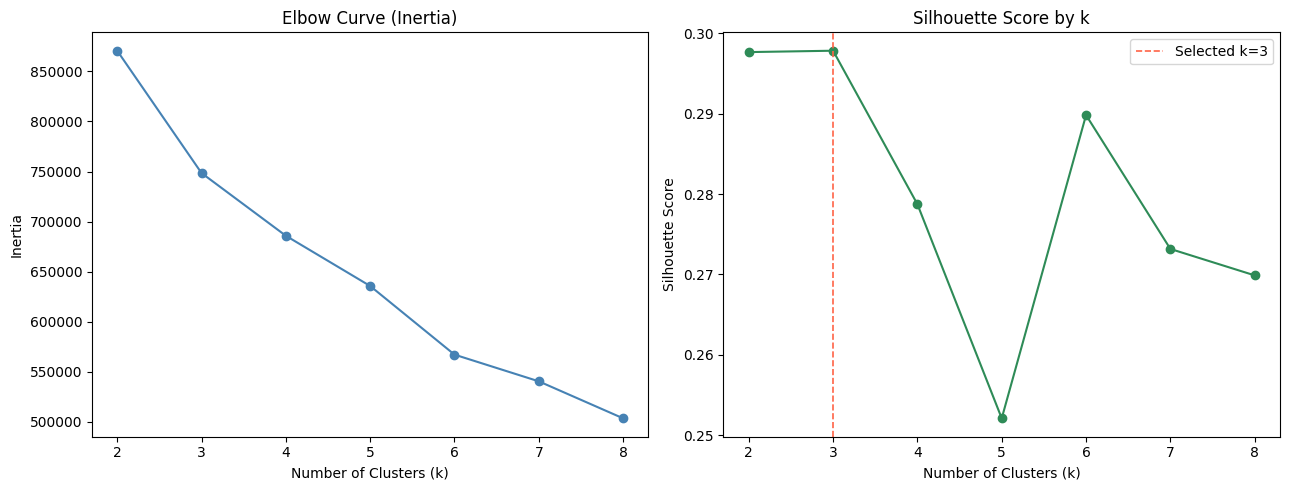

Saved plot: analysis_assets\step10_kmeans_cluster_scatter.png


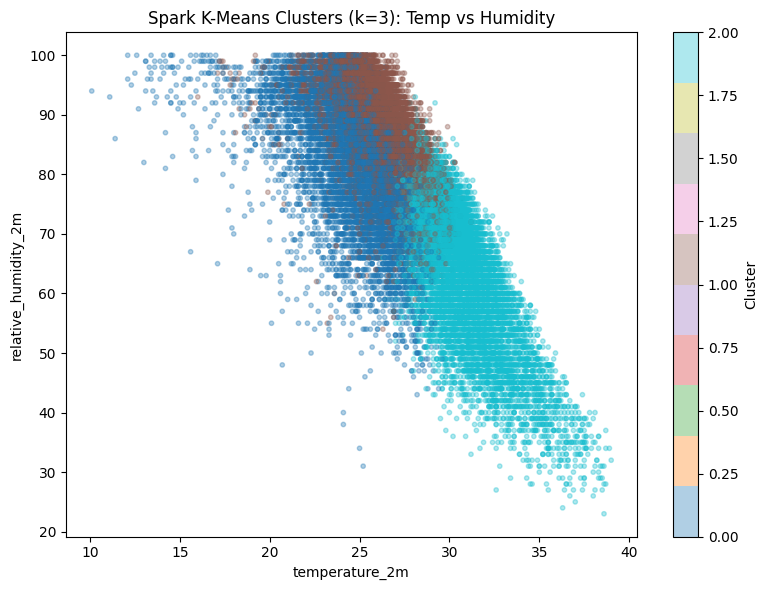

C:\Users\Ryan\AppData\Local\Temp\ipykernel_5388\3837933505.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved plot: analysis_assets\step10_kmeans_iter1_iter2_scatter.png


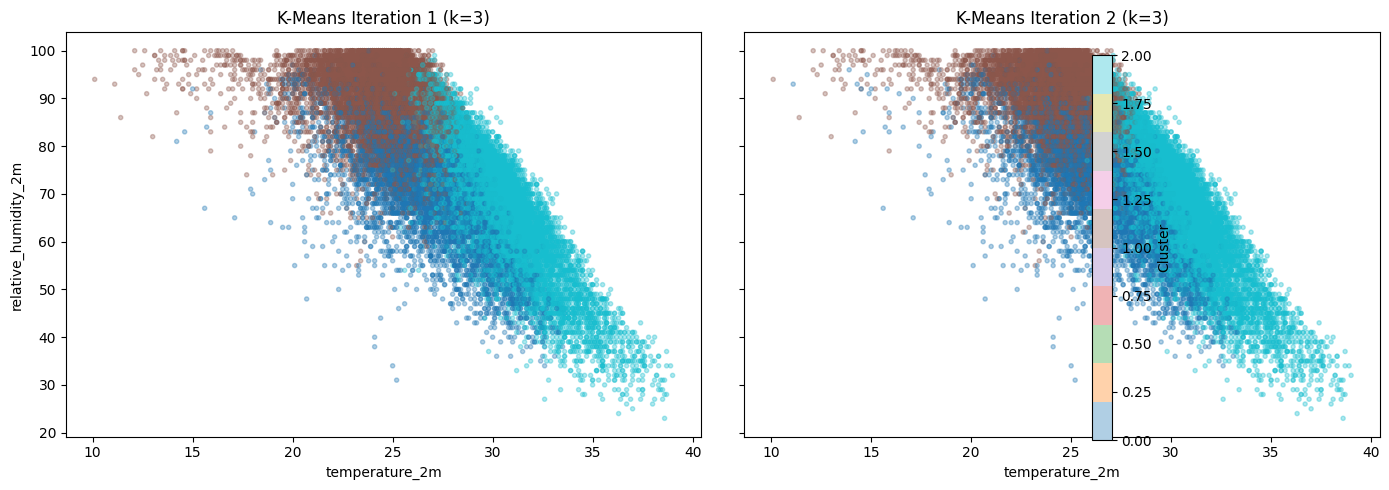


Cluster profile means:
         temperature_2m  relative_humidity_2m  apparent_temperature  \
cluster                                                               
0                 24.85                 83.37                 28.24   
1                 26.20                 88.43                 31.32   
2                 30.50                 64.90                 34.96   

         precipitation  wind_speed_10m  pressure_msl  cloud_cover   hour  \
cluster                                                                    
0                 0.14           10.07       1013.16        57.33  10.26   
1                 0.52            7.39       1009.24        67.16  11.06   
2                 0.09           11.42       1010.10        41.78  13.58   

         month  
cluster         
0         2.27  
1         8.57  
2         4.94  

Spark K-Means baseline complete. Fine-tuning is deferred for a later step.


In [26]:
# Step 10.2: Train Spark K-Means baseline and visualize cluster quality
k_values = list(range(2, 9))
inertia_scores = []
silhouette_scores = []
models = {}

for k in k_values:
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=42, maxIter=30)
    model = km.fit(cluster_ml_df)
    pred_df = model.transform(cluster_ml_df)

    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")
    silhouette = evaluator.evaluate(pred_df)

    inertia_scores.append(model.summary.trainingCost)
    silhouette_scores.append(silhouette)
    models[k] = model

k_results = pd.DataFrame({
    "k": k_values,
    "inertia": inertia_scores,
    "silhouette": silhouette_scores
})
print("K search results:")
print(k_results.to_string(index=False))

# Choose best k by maximum silhouette score for baseline selection.
best_k = int(k_results.loc[k_results["silhouette"].idxmax(), "k"])
print("\nSelected baseline k (max silhouette):", best_k)

baseline_model = models[best_k]
baseline_pred_df = baseline_model.transform(cluster_ml_df).cache()

# Visualization 1: Elbow + Silhouette trends
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(k_values, inertia_scores, marker="o", color="steelblue")
ax[0].set_title("Elbow Curve (Inertia)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, silhouette_scores, marker="o", color="seagreen")
ax[1].axvline(best_k, color="tomato", linestyle="--", linewidth=1.2, label=f"Selected k={best_k}")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].legend()

plt.tight_layout()
quality_path = os.path.join("analysis_assets", "step10_kmeans_quality_curves.png")
fig.savefig(quality_path, dpi=150, bbox_inches="tight")
print("Saved plot:", quality_path)
plt.show()

# Convert a manageable sample to pandas for plotting/profile tables.
plot_pdf = baseline_pred_df.select(*cluster_cols, "cluster").limit(40000).toPandas()

# Visualization 2: Cluster scatter (temperature vs humidity)
fig2, ax2 = plt.subplots(figsize=(8, 6))
scatter = ax2.scatter(
    plot_pdf["temperature_2m"],
    plot_pdf["relative_humidity_2m"],
    c=plot_pdf["cluster"],
    cmap="tab10",
    s=10,
    alpha=0.35
)
ax2.set_title(f"Spark K-Means Clusters (k={best_k}): Temp vs Humidity")
ax2.set_xlabel("temperature_2m")
ax2.set_ylabel("relative_humidity_2m")
plt.colorbar(scatter, ax=ax2, label="Cluster")
plt.tight_layout()
scatter_path = os.path.join("analysis_assets", "step10_kmeans_cluster_scatter.png")
fig2.savefig(scatter_path, dpi=150, bbox_inches="tight")
print("Saved plot:", scatter_path)
plt.show()

# Visualization 3: Iteration snapshots (maxIter=1 and maxIter=2) at selected k
iter1_model = KMeans(featuresCol="features", predictionCol="cluster", k=best_k, seed=42, maxIter=1).fit(cluster_ml_df)
iter2_model = KMeans(featuresCol="features", predictionCol="cluster", k=best_k, seed=42, maxIter=2).fit(cluster_ml_df)

iter1_pdf = iter1_model.transform(cluster_ml_df).select("temperature_2m", "relative_humidity_2m", "cluster").limit(40000).toPandas()
iter2_pdf = iter2_model.transform(cluster_ml_df).select("temperature_2m", "relative_humidity_2m", "cluster").limit(40000).toPandas()

fig3, ax3 = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
sc1 = ax3[0].scatter(
    iter1_pdf["temperature_2m"],
    iter1_pdf["relative_humidity_2m"],
    c=iter1_pdf["cluster"],
    cmap="tab10",
    s=9,
    alpha=0.35
)
ax3[0].set_title(f"K-Means Iteration 1 (k={best_k})")
ax3[0].set_xlabel("temperature_2m")
ax3[0].set_ylabel("relative_humidity_2m")

sc2 = ax3[1].scatter(
    iter2_pdf["temperature_2m"],
    iter2_pdf["relative_humidity_2m"],
    c=iter2_pdf["cluster"],
    cmap="tab10",
    s=9,
    alpha=0.35
)
ax3[1].set_title(f"K-Means Iteration 2 (k={best_k})")
ax3[1].set_xlabel("temperature_2m")

fig3.colorbar(sc2, ax=ax3.ravel().tolist(), label="Cluster")
plt.tight_layout()
iter_path = os.path.join("analysis_assets", "step10_kmeans_iter1_iter2_scatter.png")
fig3.savefig(iter_path, dpi=150, bbox_inches="tight")
print("Saved plot:", iter_path)
plt.show()

# Cluster profile table for interpretation
cluster_profile = (
    plot_pdf.groupby("cluster")[cluster_cols]
    .mean()
    .round(2)
    .sort_index()
)
print("\nCluster profile means:")
print(cluster_profile)

print("\nSpark K-Means baseline complete. Fine-tuning is deferred for a later step.")